# AgriMind Phase 2 — Federated Learning CNN

**Run-ready local Windows notebook**

This notebook is prepared for the project structure:

```text
E:\AI Project\AgriMind_Project
├── datasets\Tomato leaf disease detection\train
├── datasets\Tomato leaf disease detection\val
├── models\phase2_federated_cnn
├── results\phase2_federated_cnn
└── screenshots\phase2_federated_cnn
```

Run the cells from top to bottom. Do not use Google Colab mount or `/content/...` paths.


In [1]:
# ============================================================
# Block 1: Environment setup and imports
# ============================================================

import os
import sys
import json
import gc
import pathlib
import subprocess

# Reduce possible CPU/thread issues on Windows
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("TF_NUM_INTRAOP_THREADS", "1")
os.environ.setdefault("TF_NUM_INTEROP_THREADS", "1")

# Install only missing packages
required_packages = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "sklearn": "scikit-learn",
    "tensorflow": "tensorflow"
}

for import_name, package_name in required_packages.items():
    try:
        __import__(import_name)
    except ModuleNotFoundError:
        print(f"Installing missing package: {package_name}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

try:
    from IPython.display import display
except Exception:
    display = print

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))


TensorFlow version: 2.21.0
GPU available: []


In [2]:
# ============================================================
# Block 2: Local project paths
# ============================================================

PROJECT_DIR = r"E:\AI Project\AgriMind_Project"

DATASET_ROOT = os.path.join(
    PROJECT_DIR,
    "datasets",
    "Tomato leaf disease detection"
)

train_dir = os.path.join(DATASET_ROOT, "train")
test_dir = os.path.join(DATASET_ROOT, "val")

MODEL_DIR = os.path.join(PROJECT_DIR, "models", "phase2_federated_cnn")
RESULTS_DIR = os.path.join(PROJECT_DIR, "results", "phase2_federated_cnn")
SCREENSHOTS_DIR = os.path.join(PROJECT_DIR, "screenshots", "phase2_federated_cnn")

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(SCREENSHOTS_DIR, exist_ok=True)

print("Checking local dataset paths")
print("----------------------------")
print("Dataset root exists:", os.path.exists(DATASET_ROOT))
print("Train exists:", os.path.exists(train_dir))
print("Test exists:", os.path.exists(test_dir))
print("Train path:", train_dir)
print("Test path:", test_dir)

if not os.path.exists(train_dir):
    raise FileNotFoundError(f"Train directory not found: {train_dir}")

if not os.path.exists(test_dir):
    raise FileNotFoundError(f"Test directory not found: {test_dir}")


Checking local dataset paths
----------------------------
Dataset root exists: True
Train exists: True
Test exists: True
Train path: E:\AI Project\AgriMind_Project\datasets\Tomato leaf disease detection\train
Test path: E:\AI Project\AgriMind_Project\datasets\Tomato leaf disease detection\val


In [3]:
# ============================================================
# Block 3: Read class names from train folder
# ============================================================

train_path = pathlib.Path(train_dir)

class_names = sorted([
    item.name for item in train_path.glob("*")
    if item.is_dir()
])

num_classes = len(class_names)

print("Class Information")
print("-----------------")
print("Number of classes:", num_classes)

for i, name in enumerate(class_names):
    print(i, name)

if num_classes == 0:
    raise ValueError("No class folders found inside the train directory.")


Class Information
-----------------
Number of classes: 10
0 Tomato___Bacterial_spot
1 Tomato___Early_blight
2 Tomato___Late_blight
3 Tomato___Leaf_Mold
4 Tomato___Septoria_leaf_spot
5 Tomato___Spider_mites Two-spotted_spider_mite
6 Tomato___Target_Spot
7 Tomato___Tomato_Yellow_Leaf_Curl_Virus
8 Tomato___Tomato_mosaic_virus
9 Tomato___healthy


In [4]:
# ============================================================
# Block 4: Collect training image paths and labels
# ============================================================

valid_extensions = [
    ".jpg", ".jpeg", ".png", ".bmp",
    ".JPG", ".JPEG", ".PNG", ".BMP"
]

image_paths = []
image_labels = []

for label_index, class_name in enumerate(class_names):
    class_folder = train_path / class_name

    for image_file in class_folder.iterdir():
        if image_file.is_file() and image_file.suffix in valid_extensions:
            image_paths.append(str(image_file))
            image_labels.append(label_index)

image_paths = np.array(image_paths, dtype=str)
image_labels = np.array(image_labels, dtype=np.int32)

print("Training Image Collection")
print("-------------------------")
print("Total training images:", len(image_paths))
print("Total labels:", len(image_labels))
print("Image path dtype:", image_paths.dtype)

if len(image_paths) == 0:
    raise ValueError("No training images found. Check the train folder structure.")


Training Image Collection
-------------------------
Total training images: 10000
Total labels: 10000
Image path dtype: <U238


In [5]:
# ============================================================
# Block 5: Shuffle and split training data into FL train + validation
# ============================================================

SEED = 123
np.random.seed(SEED)

indices = np.arange(len(image_paths))
np.random.shuffle(indices)

image_paths = image_paths[indices]
image_labels = image_labels[indices]

val_ratio = 0.15
val_size = int(len(image_paths) * val_ratio)

val_paths = image_paths[:val_size]
val_labels = image_labels[:val_size]

fl_train_paths = image_paths[val_size:]
fl_train_labels = image_labels[val_size:]

print("Train/Validation Split")
print("----------------------")
print("Federated training images:", len(fl_train_paths))
print("Validation images:", len(val_paths))

if len(fl_train_paths) == 0:
    raise ValueError("Federated training data is empty.")

if len(val_paths) == 0:
    raise ValueError("Validation data is empty.")


Train/Validation Split
----------------------
Federated training images: 8500
Validation images: 1500


In [6]:
# ============================================================
# Block 6: Split federated training data into clients
# ============================================================

NUM_CLIENTS = 4

client_paths = np.array_split(fl_train_paths, NUM_CLIENTS)
client_labels = np.array_split(fl_train_labels, NUM_CLIENTS)

print("Client Split")
print("------------")

for i in range(NUM_CLIENTS):
    print(f"Client {i + 1} images:", len(client_paths[i]))

if len(client_paths) != NUM_CLIENTS:
    raise ValueError("Client split failed.")

if any(len(paths) == 0 for paths in client_paths):
    raise ValueError("At least one client has no images. Reduce NUM_CLIENTS or check dataset size.")


Client Split
------------
Client 1 images: 2125
Client 2 images: 2125
Client 3 images: 2125
Client 4 images: 2125


In [7]:
# ============================================================
# Block 7: Image preprocessing and TensorFlow dataset creation
# ============================================================

IMG_SIZE = 128
BATCH_SIZE = 32


def load_and_preprocess_image(file_path, label):
    file_path = tf.cast(file_path, tf.string)

    image = tf.io.read_file(file_path)
    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image.set_shape([None, None, 3])
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32) / 255.0

    return image, label


def create_dataset(paths, labels, shuffle=True):
    paths = np.array(paths, dtype=str)
    labels = np.array(labels, dtype=np.int32)

    if len(paths) == 0:
        raise ValueError("Cannot create dataset because paths array is empty.")

    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))

    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(paths), seed=SEED)

    dataset = dataset.map(
        load_and_preprocess_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset


client_datasets = []

for i in range(NUM_CLIENTS):
    ds = create_dataset(client_paths[i], client_labels[i], shuffle=True)
    client_datasets.append(ds)

val_ds = create_dataset(val_paths, val_labels, shuffle=False)

print("TensorFlow datasets created successfully.")
print("Client datasets:", len(client_datasets))


TensorFlow datasets created successfully.
Client datasets: 4


In [8]:
# ============================================================
# Block 8: Create test dataset from val folder
# ============================================================

test_path = pathlib.Path(test_dir)

test_image_paths = []
test_image_labels = []

for label_index, class_name in enumerate(class_names):
    class_folder = test_path / class_name

    if not class_folder.exists():
        print("Missing test class folder:", class_folder)
        continue

    for image_file in class_folder.iterdir():
        if image_file.is_file() and image_file.suffix in valid_extensions:
            test_image_paths.append(str(image_file))
            test_image_labels.append(label_index)

test_image_paths = np.array(test_image_paths, dtype=str)
test_image_labels = np.array(test_image_labels, dtype=np.int32)

print("Test Image Collection")
print("---------------------")
print("Test images:", len(test_image_paths))
print("Test labels:", len(test_image_labels))
print("Test path dtype:", test_image_paths.dtype)

if len(test_image_paths) == 0:
    raise ValueError("No test images found. Check the val folder structure.")

test_ds = create_dataset(test_image_paths, test_image_labels, shuffle=False)

print("Test dataset created successfully.")


Missing test class folder: E:\AI Project\AgriMind_Project\datasets\Tomato leaf disease detection\val\Tomato___Target_Spot
Missing test class folder: E:\AI Project\AgriMind_Project\datasets\Tomato leaf disease detection\val\Tomato___Tomato_Yellow_Leaf_Curl_Virus
Missing test class folder: E:\AI Project\AgriMind_Project\datasets\Tomato leaf disease detection\val\Tomato___Tomato_mosaic_virus
Missing test class folder: E:\AI Project\AgriMind_Project\datasets\Tomato leaf disease detection\val\Tomato___healthy
Test Image Collection
---------------------
Test images: 584
Test labels: 584
Test path dtype: <U240
Test dataset created successfully.


In [9]:
# ============================================================
# Block 9: Create CNN model function and global model
# ============================================================


def create_cnn_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

        tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
        tf.keras.layers.MaxPooling2D(2, 2),

        tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
        tf.keras.layers.MaxPooling2D(2, 2),

        tf.keras.layers.Conv2D(128, (3, 3), activation="relu"),
        tf.keras.layers.MaxPooling2D(2, 2),

        tf.keras.layers.Flatten(),

        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dropout(0.3),

        tf.keras.layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


global_model = create_cnn_model()

global_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,930 (12.61 MB)

 Trainable params: 3,305,930 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# ============================================================
# Block 10: Federated averaging function
# ============================================================


def average_weights(local_weights):
    averaged_weights = []

    for weights in zip(*local_weights):
        averaged_layer = np.mean(
            np.stack(weights, axis=0),
            axis=0
        )
        averaged_weights.append(averaged_layer)

    return averaged_weights


In [11]:
# ============================================================
# Block 11: Train using Federated Learning
# ============================================================

NUM_ROUNDS = 5
LOCAL_EPOCHS = 1

round_accuracies = []
round_losses = []

print("Starting Federated Learning Training")
print("------------------------------------")

for round_num in range(NUM_ROUNDS):
    print()
    print(f"Federated Round {round_num + 1}/{NUM_ROUNDS}")

    local_weights = []

    for client_id in range(NUM_CLIENTS):
        print(f"Training Client {client_id + 1}")

        local_model = create_cnn_model()

        local_model.set_weights(global_model.get_weights())

        local_model.fit(
            client_datasets[client_id],
            epochs=LOCAL_EPOCHS,
            verbose=0
        )

        local_weights.append([
            weight.copy() for weight in local_model.get_weights()
        ])

        del local_model
        gc.collect()

    new_global_weights = average_weights(local_weights)

    global_model.set_weights(new_global_weights)

    val_loss, val_accuracy = global_model.evaluate(val_ds, verbose=0)

    round_losses.append(val_loss)
    round_accuracies.append(val_accuracy)

    print(f"Validation Loss: {val_loss:.4f}")
    print(f"Validation Accuracy: {val_accuracy:.4f}")

Starting Federated Learning Training
------------------------------------

Federated Round 1/5
Training Client 1


e:\AI Project\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


Training Client 2
Training Client 3
Training Client 4
Validation Loss: 2.1091
Validation Accuracy: 0.3353

Federated Round 2/5
Training Client 1
Training Client 2
Training Client 3
Training Client 4
Validation Loss: 1.0795
Validation Accuracy: 0.6800

Federated Round 3/5
Training Client 1
Training Client 2
Training Client 3
Training Client 4
Validation Loss: 0.7600
Validation Accuracy: 0.7540

Federated Round 4/5
Training Client 1
Training Client 2
Training Client 3
Training Client 4
Validation Loss: 0.6316
Validation Accuracy: 0.7913

Federated Round 5/5
Training Client 1
Training Client 2
Training Client 3
Training Client 4
Validation Loss: 0.5282
Validation Accuracy: 0.8187


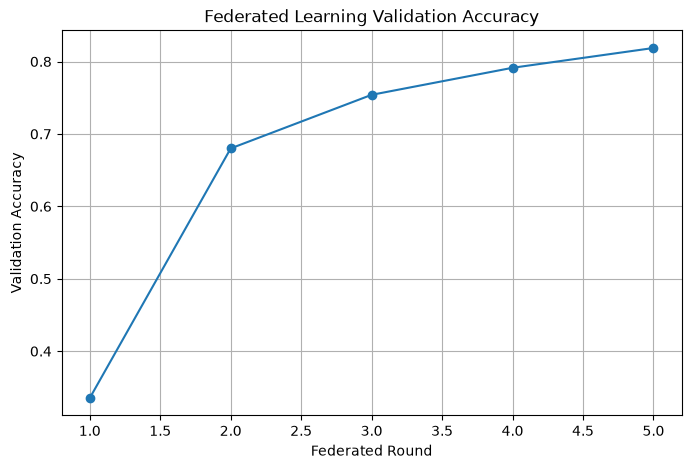

Accuracy graph saved at: E:\AI Project\AgriMind_Project\screenshots\phase2_federated_cnn\phase2_federated_accuracy_graph.png


In [12]:
# ============================================================
# Block 12: Plot and save federated validation accuracy graph
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(range(1, NUM_ROUNDS + 1), round_accuracies, marker="o")
plt.xlabel("Federated Round")
plt.ylabel("Validation Accuracy")
plt.title("Federated Learning Validation Accuracy")
plt.grid(True)

accuracy_graph_path = os.path.join(
    SCREENSHOTS_DIR,
    "phase2_federated_accuracy_graph.png"
)

plt.savefig(accuracy_graph_path, dpi=300, bbox_inches="tight")
plt.show()

print("Accuracy graph saved at:", accuracy_graph_path)


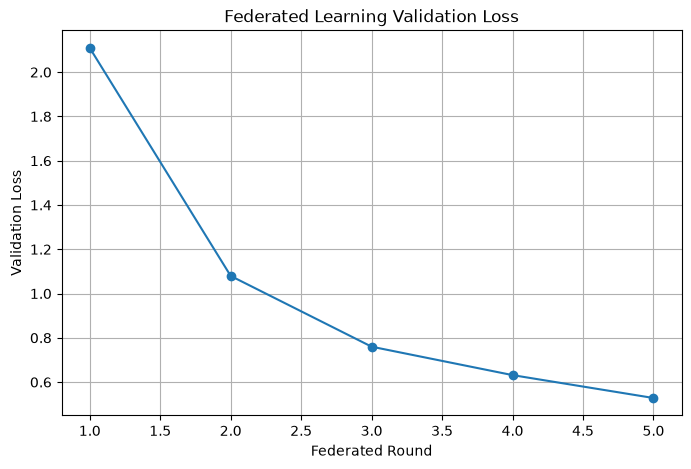

Loss graph saved at: E:\AI Project\AgriMind_Project\screenshots\phase2_federated_cnn\phase2_federated_loss_graph.png


In [13]:
# ============================================================
# Block 13: Plot and save federated validation loss graph
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(range(1, NUM_ROUNDS + 1), round_losses, marker="o")
plt.xlabel("Federated Round")
plt.ylabel("Validation Loss")
plt.title("Federated Learning Validation Loss")
plt.grid(True)

loss_graph_path = os.path.join(
    SCREENSHOTS_DIR,
    "phase2_federated_loss_graph.png"
)

plt.savefig(loss_graph_path, dpi=300, bbox_inches="tight")
plt.show()

print("Loss graph saved at:", loss_graph_path)


In [14]:
# ============================================================
# Block 14: Evaluate final federated model on test dataset
# ============================================================

test_loss, test_accuracy = global_model.evaluate(test_ds)

print("Federated Model Test Evaluation")
print("-------------------------------")
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)


19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 117ms/step - accuracy: 0.7226 - loss: 0.7409
Federated Model Test Evaluation
-------------------------------
Test Loss: 0.7409313917160034
Test Accuracy: 0.7226027250289917


In [16]:
# ============================================================
# Block 15: Calculate accuracy, precision, recall, and F1-score
# ============================================================

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = global_model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

fed_accuracy = accuracy_score(y_true, y_pred)
fed_precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
fed_recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
fed_f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

print("Final Federated Learning Evaluation")
print("-----------------------------------")
print("Accuracy :", fed_accuracy)
print("Precision:", fed_precision)
print("Recall   :", fed_recall)
print("F1-score :", fed_f1)

print()
print("Detailed Classification Report")

print(classification_report(
    y_true,
    y_pred,
    labels=range(len(class_names)),
    target_names=class_names,
    zero_division=0
))

Final Federated Learning Evaluation
-----------------------------------
Accuracy : 0.7226027397260274
Precision: 0.8082644770681449
Recall   : 0.7226027397260274
F1-score : 0.761022818136014

Detailed Classification Report
                                               precision    recall  f1-score   support

                      Tomato___Bacterial_spot       0.88      0.91      0.89       100
                        Tomato___Early_blight       0.76      0.61      0.68       100
                         Tomato___Late_blight       0.84      0.67      0.74       100
                           Tomato___Leaf_Mold       0.80      0.71      0.75       100
                  Tomato___Septoria_leaf_spot       0.67      0.66      0.66       100
Tomato___Spider_mites Two-spotted_spider_mite       0.93      0.79      0.85        84
                         Tomato___Target_Spot       0.00      0.00      0.00         0
       Tomato___Tomato_Yellow_Leaf_Curl_Virus       0.00      0.00      0.00    

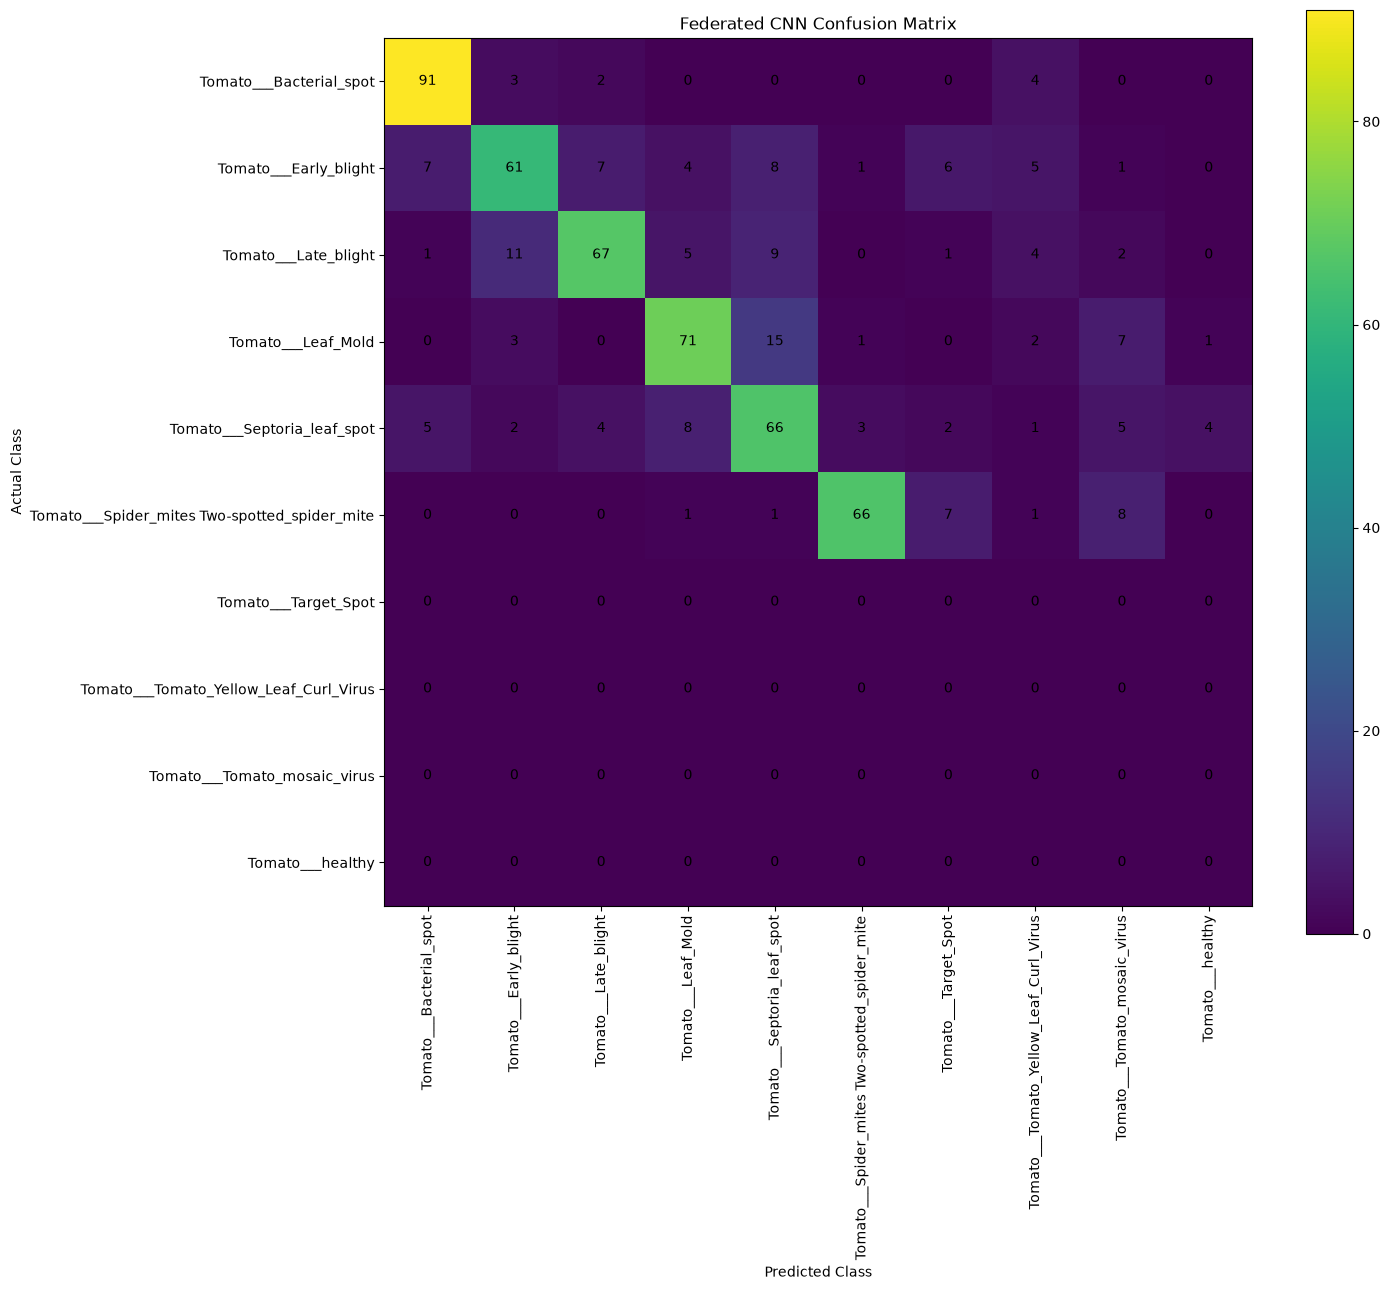

Confusion matrix saved at: E:\AI Project\AgriMind_Project\screenshots\phase2_federated_cnn\phase2_federated_confusion_matrix.png


In [17]:
# ============================================================
# Block 16: Confusion matrix and save image
# ============================================================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(14, 12))
plt.imshow(cm)
plt.title("Federated CNN Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=90)
plt.yticks(tick_marks, class_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

confusion_matrix_path = os.path.join(
    SCREENSHOTS_DIR,
    "phase2_federated_confusion_matrix.png"
)

plt.savefig(confusion_matrix_path, dpi=300, bbox_inches="tight")
plt.show()

print("Confusion matrix saved at:", confusion_matrix_path)


In [18]:
# ============================================================
# Block 17: Save federated model, class names, and results locally
# ============================================================

keras_model_path = os.path.join(MODEL_DIR, "agrimind_federated_cnn_model.keras")
h5_model_path = os.path.join(MODEL_DIR, "agrimind_federated_cnn_model.h5")

global_model.save(keras_model_path)
global_model.save(h5_model_path)

class_names_path = os.path.join(MODEL_DIR, "class_names.json")

with open(class_names_path, "w") as f:
    json.dump(class_names, f)

phase2_results = pd.DataFrame([{
    "Module": "Privacy-Preserving Disease Detection",
    "Model": "Federated CNN",
    "Accuracy": fed_accuracy,
    "Precision": fed_precision,
    "Recall": fed_recall,
    "F1-score": fed_f1,
    "Test Loss": test_loss
}])

phase2_results_path = os.path.join(RESULTS_DIR, "phase2_federated_cnn_results.csv")
phase2_results.to_csv(phase2_results_path, index=False)

print("Phase 2 Federated CNN files saved successfully.")
print("Keras model saved at:", keras_model_path)
print("H5 model saved at:", h5_model_path)
print("Class names saved at:", class_names_path)
print("Results saved at:", phase2_results_path)


Phase 2 Federated CNN files saved successfully.
Keras model saved at: E:\AI Project\AgriMind_Project\models\phase2_federated_cnn\agrimind_federated_cnn_model.keras
H5 model saved at: E:\AI Project\AgriMind_Project\models\phase2_federated_cnn\agrimind_federated_cnn_model.h5
Class names saved at: E:\AI Project\AgriMind_Project\models\phase2_federated_cnn\class_names.json
Results saved at: E:\AI Project\AgriMind_Project\results\phase2_federated_cnn\phase2_federated_cnn_results.csv


In [19]:
# ============================================================
# Block 18: Load saved model and verify
# ============================================================

loaded_federated_model = tf.keras.models.load_model(keras_model_path)

print("Federated model loaded successfully.")

loaded_test_loss, loaded_test_accuracy = loaded_federated_model.evaluate(test_ds)

print("Loaded Federated Model Test Loss:", loaded_test_loss)
print("Loaded Federated Model Test Accuracy:", loaded_test_accuracy)


e:\AI Project\.venv\Lib\site-packages\keras\src\saving\saving_lib.py:843: UserWarning: Skipping variable loading for optimizer 'adam', because it has 22 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Federated model loaded successfully.
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 115ms/step - accuracy: 0.7226 - loss: 0.7409
Loaded Federated Model Test Loss: 0.7409313917160034
Loaded Federated Model Test Accuracy: 0.7226027250289917


In [20]:
# ============================================================
# Block 19: Centralized CNN vs Federated CNN comparison
# ============================================================

phase1_results_path = os.path.join(
    PROJECT_DIR,
    "results",
    "phase1_cnn",
    "phase1_cnn_results.csv"
)

if os.path.exists(phase1_results_path):
    phase1_df = pd.read_csv(phase1_results_path)

    central_accuracy = phase1_df.loc[0, "Accuracy"]
    central_precision = phase1_df.loc[0, "Precision"]
    central_recall = phase1_df.loc[0, "Recall"]
    central_f1 = phase1_df.loc[0, "F1-score"]

    print("Phase 1 results loaded from:", phase1_results_path)

else:
    print("Phase 1 result file not found.")
    print("Using temporary fallback values. Replace later with actual Phase 1 results if needed.")

    central_accuracy = 0.846
    central_precision = 0.8604
    central_recall = 0.846
    central_f1 = 0.8464

comparison_data = {
    "Model": ["Centralized CNN", "Federated CNN"],
    "Accuracy": [central_accuracy, fed_accuracy],
    "Precision": [central_precision, fed_precision],
    "Recall": [central_recall, fed_recall],
    "F1-score": [central_f1, fed_f1]
}

comparison_df = pd.DataFrame(comparison_data)

comparison_path = os.path.join(
    RESULTS_DIR,
    "centralized_vs_federated_comparison.csv"
)

comparison_df.to_csv(comparison_path, index=False)

print("Centralized CNN vs Federated CNN Comparison")
print("-------------------------------------------")
display(comparison_df)

print("Comparison table saved at:", comparison_path)


Phase 1 results loaded from: E:\AI Project\AgriMind_Project\results\phase1_cnn\phase1_cnn_results.csv
Centralized CNN vs Federated CNN Comparison
-------------------------------------------


,Model,Accuracy,Precision,Recall,F1-score
0,Centralized CNN,0.864726,0.894896,0.864726,0.878731
1,Federated CNN,0.722603,0.808264,0.722603,0.761023


Comparison table saved at: E:\AI Project\AgriMind_Project\results\phase2_federated_cnn\centralized_vs_federated_comparison.csv


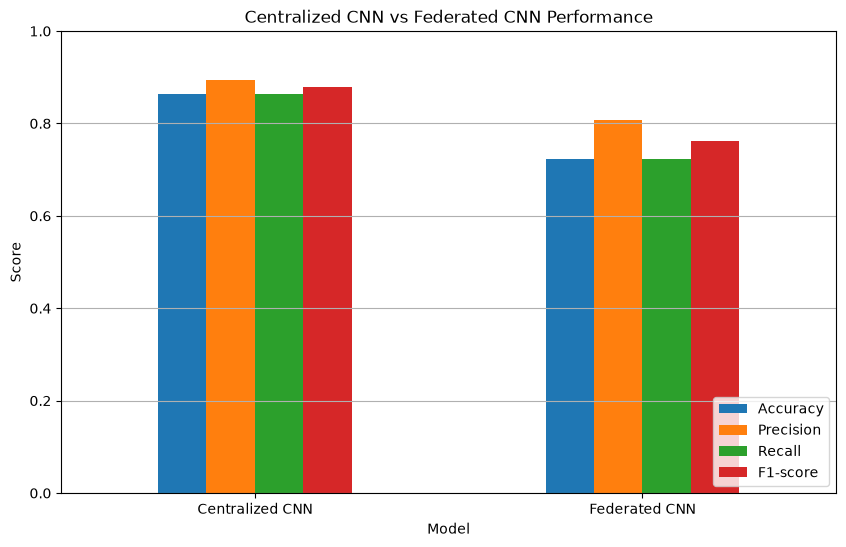

Comparison graph saved at: E:\AI Project\AgriMind_Project\screenshots\phase2_federated_cnn\phase2_centralized_vs_federated_comparison.png


In [21]:
# ============================================================
# Block 20: Comparison graph and save image
# ============================================================

comparison_df.set_index("Model")[[
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score"
]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Centralized CNN vs Federated CNN Performance")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.legend(loc="lower right")

comparison_graph_path = os.path.join(
    SCREENSHOTS_DIR,
    "phase2_centralized_vs_federated_comparison.png"
)

plt.savefig(comparison_graph_path, dpi=300, bbox_inches="tight")
plt.show()

print("Comparison graph saved at:", comparison_graph_path)


In [22]:
# ============================================================
# Block 21: Final summary
# ============================================================

print("============================================================")
print("AgriMind Phase 2 Federated Learning CNN Completed Successfully")
print("============================================================")
print("Model folder      :", MODEL_DIR)
print("Results folder    :", RESULTS_DIR)
print("Screenshots folder:", SCREENSHOTS_DIR)
print("Final Test Accuracy:", fed_accuracy)
print("Final Precision    :", fed_precision)
print("Final Recall       :", fed_recall)
print("Final F1-score     :", fed_f1)
print("============================================================")


AgriMind Phase 2 Federated Learning CNN Completed Successfully
Model folder      : E:\AI Project\AgriMind_Project\models\phase2_federated_cnn
Results folder    : E:\AI Project\AgriMind_Project\results\phase2_federated_cnn
Screenshots folder: E:\AI Project\AgriMind_Project\screenshots\phase2_federated_cnn
Final Test Accuracy: 0.7226027397260274
Final Precision    : 0.8082644770681449
Final Recall       : 0.7226027397260274
Final F1-score     : 0.761022818136014
